# IA na medicina: diagnóstico, avaliação, prognóstico e tratamento
### Quatro demonstrações com dados reais, pensadas para a infectologia

Este notebook percorre, em quatro etapas, os principais usos de inteligência artificial ao longo do cuidado com o paciente:

| Etapa | Pergunta clínica | Técnica | Dados |
|---|---|---|---|
| **1. Diagnóstico** | Há pneumonia ou outro achado neste raio-X? E onde? | rede neural **DenseNet121** já treinada + **Grad-CAM** | raio-X de tórax do NIH (ChestX-ray14) |
| **2. Avaliação** | Esse teste é bom mesmo? Quanto confiar num resultado positivo? | **sensibilidade, especificidade, VPP/VPN, curva ROC**, bootstrap e calibração | as previsões da etapa 1 |
| **3. Prognóstico** | Qual a chance de o paciente evoluir mal ao longo do tempo? | **Kaplan-Meier**, teste **log-rank** e modelo de **Cox** | ensaio clínico **ACTG 175** (HIV) |
| **4. Tratamento** | O tratamento funciona? E **para quem** funciona mais? | **odds ratio**, **redução absoluta de risco** e um modelo de ML (**T-learner**) | o mesmo ensaio ACTG 175 |

> ⚠️ Material **didático**: os modelos e análises aqui não servem para decisões clínicas.

As técnicas vêm da especialização *AI for Medicine* (DeepLearning.AI). Nas etapas 3 e 4 trocamos os dados originais por um ensaio clínico de **HIV**, mais próximo da infectologia.

## 0. Como rodar este notebook

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pasteurjr/notebookvideoaulas/blob/main/02_ia_na_medicina/notebook/ia_na_medicina_infectologia.ipynb)

O curso tem duas partes, com a **mesma estrutura de pastas** (uma pasta por aula):

| O quê | Onde |
|---|---|
| **Código**: os notebooks e os arquivos que eles usam | GitHub: **https://github.com/pasteurjr/notebookvideoaulas** |
| **Dados, vídeos e roteiros** de cada aula | Google Drive: **[pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)** |

**Antes de começar, leia o [README.md da pasta do Google Drive](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)**: ele explica como baixar e organizar os dados de todas as aulas.

**Esta aula (`02_ia_na_medicina`) usa:** a pasta **`dados/`** do Google Drive: raio-X de tórax do NIH e o ensaio clínico ACTG 175 (~240 MB); **GPU** (no Colab, a T4 gratuita é suficiente); nenhuma chave de API.

### Opção A: Google Colab (recomendado)

1. **Coloque os dados do curso no seu Google Drive** (uma vez só, vale para todas as aulas). Abra a [pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) do curso, **baixe** a pasta e faça o **upload** dela para o seu **Meu Drive**, mantendo o nome e as subpastas. Os dados desta aula precisam ficar em **`MyDrive/notebooksvideos/02_ia_na_medicina/notebook/dados`**. Mais rápido: em vez de baixar e subir, clique com o botão direito na pasta → **Organizar → Adicionar atalho** → **Meu Drive**.
2. **Abra este notebook no Colab** pelo botão **Abrir no Colab** acima (ele abre direto do GitHub).
3. **Ative a GPU gratuita:** **Ambiente de execução → Alterar o tipo de ambiente de execução → GPU T4**.
4. **Rode a célula de preparação logo abaixo.** Ela clona o repositório do GitHub para o Colab, monta o seu Google Drive (autorize o acesso), copia os dados desta aula e instala só as bibliotecas que faltarem.
5. Depois: **Ambiente de execução → Executar tudo**.

**Se aparecer erro de biblioteca** (`ModuleNotFoundError`, `ImportError` ou erro de versão): crie uma célula nova, rode o comando abaixo, depois vá em **Ambiente de execução → Reiniciar sessão** e rode a célula de preparação de novo.

```
!pip install tensorflow keras scikit-learn lifelines matplotlib pandas
```

### Opção B: no seu computador

Basta baixar. Pré-requisito: [Miniconda](https://docs.conda.io/en/latest/miniconda.html) (ou Anaconda) e Git. No terminal:

```bash
git clone https://github.com/pasteurjr/notebookvideoaulas.git
cd notebookvideoaulas
conda create -n notecursos python=3.12 -y
conda activate notecursos
pip install -r requirements.txt
cd 02_ia_na_medicina/notebook
jupyter notebook ia_na_medicina_infectologia.ipynb
```

**Dados:** baixe da [pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) a pasta **`02_ia_na_medicina/notebook/dados`** e coloque em `notebookvideoaulas/02_ia_na_medicina/notebook/dados`.

No computador local, a célula de preparação detecta que não está no Colab e não faz nada.

### Dica: peça ajuda a um assistente de IA

Um assistente de programação, como o **Claude Code** ou o **Codex**, faz toda essa preparação sozinho. Abra o assistente numa pasta vazia e peça, por exemplo:

> Clone https://github.com/pasteurjr/notebookvideoaulas. Crie o ambiente conda `notecursos` com Python 3.12 e instale: `pip install -r requirements.txt`. Baixe da pasta notebooksvideos do Google Drive (https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) a pasta `02_ia_na_medicina/notebook/dados` e coloque em `02_ia_na_medicina/notebook/dados`. Por fim, abra `02_ia_na_medicina/notebook/ia_na_medicina_infectologia.ipynb` no Jupyter.


In [1]:
# PREPARAÇÃO DO AMBIENTE NO GOOGLE COLAB (igual em todos os notebooks do curso; no computador local não faz nada)
AULA = "02_ia_na_medicina/notebook"                           # pasta desta aula no repositório
USA_DADOS_DO_DRIVE = True                                     # copia os dados da pasta "notebooksvideos" do Drive
PACOTES = {"tensorflow": "tensorflow", "keras": "keras", "sklearn": "scikit-learn", "lifelines": "lifelines", "matplotlib": "matplotlib", "pandas": "pandas"}   # módulo: pacote pip
SECRETS = []                                   # chaves lidas dos Secrets do Colab (ícone 🔑)

import os, sys, shutil, subprocess, importlib.util

if "google.colab" in sys.modules:
    # 1) Código: clona o repositório do GitHub para o Colab
    if not os.path.exists("/content/notebookvideoaulas"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pasteurjr/notebookvideoaulas.git",
                        "/content/notebookvideoaulas"], check=True)
    os.chdir(f"/content/notebookvideoaulas/{AULA}")

    # 2) Dados: copia da pasta "notebooksvideos" (atalho no Meu Drive) para a pasta da aula
    if USA_DADOS_DO_DRIVE and not os.path.exists("dados"):
        from google.colab import drive
        drive.mount("/content/drive")
        origem = f"/content/drive/MyDrive/notebooksvideos/{AULA}/dados"
        if not os.path.exists(origem):
            raise FileNotFoundError(f"Não encontrei {origem}. Coloque a pasta notebooksvideos do curso no seu Meu Drive "
                                    "(veja o README.md da pasta do Google Drive) e rode esta célula de novo.")
        shutil.copytree(origem, "dados")

    # 3) Bibliotecas: instala só as que a sessão do Colab ainda não tem
    faltando = [pip for modulo, pip in PACOTES.items() if importlib.util.find_spec(modulo) is None]
    if faltando:
        print("Instalando:", ", ".join(faltando))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltando], check=True)
        print("Pronto. Se o Colab pedir 'Reiniciar sessão', reinicie e rode esta célula de novo.")
    else:
        print("Todas as bibliotecas já estão instaladas no Colab.")

    # 4) Chaves de API: vêm dos Secrets do Colab (nunca escreva a chave no notebook)
    if SECRETS:
        from google.colab import userdata
        for chave in SECRETS:
            os.environ[chave] = userdata.get(chave)

    print("Pasta da aula:", os.getcwd())
    print("Conteúdo:", sorted(os.listdir(".")))
else:
    print("Ambiente local detectado: usando a pasta atual.")

Ambiente local detectado: usando a pasta atual.


## Preparação: bibliotecas

- **TensorFlow/Keras**: a rede neural da etapa 1;
- **scikit-learn**: métricas e modelos de machine learning;
- **lifelines**: análise de sobrevida (etapa 3);
- **pandas** e **matplotlib**: tabelas e gráficos.

In [2]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"       # esconde as mensagens internas do TensorFlow
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from keras.applications import DenseNet121
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

np.random.seed(42)
pd.set_option("display.precision", 3)
print("GPU:", [tf.config.experimental.get_device_details(g)["device_name"] for g in tf.config.list_physical_devices("GPU")] or "nenhuma (CPU)")

GPU: ['NVIDIA GeForce RTX 5080']


# Etapa 1: Diagnóstico por imagem
## Detectando pneumonia e outros achados em raio-X de tórax

Usamos uma amostra do **ChestX-ray14**, do NIH: raio-X de tórax, cada um marcado com **14 achados** possíveis. Vários interessam à infectologia: **pneumonia, consolidação, infiltração, derrame pleural e edema**.

É um problema **multirrótulo**: um mesmo exame pode ter vários achados ao mesmo tempo. Cada linha da tabela é uma imagem; 1 indica que o achado está presente.

In [3]:
PASTA_NIH = "dados/nih/"
treino = pd.read_csv(PASTA_NIH + "train-small.csv")
teste = pd.read_csv(PASTA_NIH + "test.csv")

ACHADOS = ["Cardiomegaly", "Emphysema", "Effusion", "Hernia", "Infiltration", "Mass", "Nodule",
           "Atelectasis", "Pneumothorax", "Pleural_Thickening", "Pneumonia", "Fibrosis", "Edema", "Consolidation"]

print(f"Treino: {len(treino)} imagens | Teste: {len(teste)} imagens | {len(ACHADOS)} achados")
teste[["Image", "PatientId", "Pneumonia", "Consolidation", "Infiltration", "Effusion", "Edema"]].head()

Treino: 1000 imagens | Teste: 420 imagens | 14 achados


,Image,PatientId,Pneumonia,Consolidation,Infiltration,Effusion,Edema
0,00021463_005.png,21463,0,0,1,1,1
1,00019733_002.png,19733,0,0,0,0,0
2,00021463_001.png,21463,0,0,0,0,0
3,00017136_020.png,17136,0,0,0,0,0
4,00027477_000.png,27477,0,0,1,0,0


### Cuidado 1: vazamento de pacientes

Um paciente costuma ter **vários exames**. Se o mesmo paciente aparece no treino e no teste, o modelo pode "reconhecer o paciente" em vez de aprender a doença, e o resultado do teste fica otimista demais. Por isso conferimos se há pacientes em comum.

In [4]:
def pacientes_em_comum(df1, df2):
    return set(df1["PatientId"]) & set(df2["PatientId"])

print("Pacientes em comum entre treino e teste:", len(pacientes_em_comum(treino, teste)))

Pacientes em comum entre treino e teste: 0


### Cuidado 2: doenças raras (desbalanceamento)

Cada achado aparece em poucos exames. Um modelo "preguiçoso", que sempre diz "não tem", acertaria quase tudo e não serviria para nada. No treinamento, isso é corrigido com uma **função de perda ponderada**, que dá peso maior aos casos positivos, que são raros.

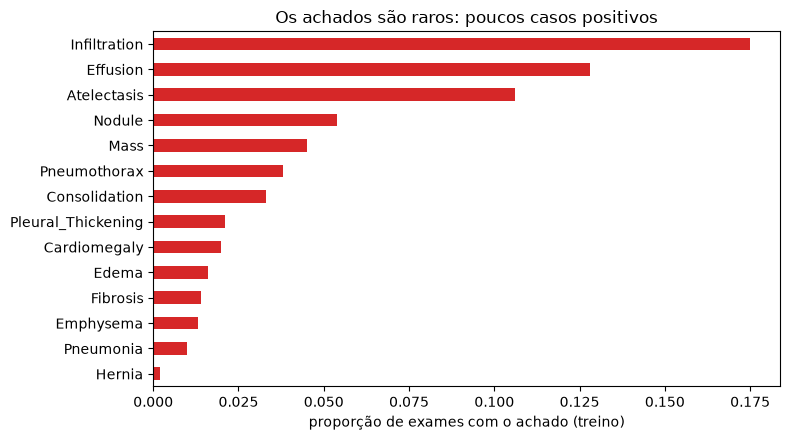

Pneumonia: 1.0% dos exames -> peso 0.99 para os positivos


In [5]:
freq_pos = treino[ACHADOS].mean().sort_values()
ax = freq_pos.plot.barh(figsize=(8, 4.5), color="#d62728")
ax.set_xlabel("proporção de exames com o achado (treino)")
ax.set_title("Os achados são raros: poucos casos positivos")
plt.tight_layout(); plt.show()

peso_positivo = 1 - treino[ACHADOS].mean()
print(f"Pneumonia: {treino['Pneumonia'].mean():.1%} dos exames -> peso {peso_positivo['Pneumonia']:.2f} para os positivos")

### O modelo: DenseNet121 já treinada

Treinar do zero exigiria mais de 100 mil imagens e horas de GPU. Usamos uma **DenseNet121** (rede convolucional de 121 camadas) **já treinada** no conjunto completo do ChestX-ray14. A última camada tem **14 saídas com ativação sigmoide**: cada uma dá, de forma independente, a probabilidade de um achado.

As imagens são redimensionadas para 320×320 pixels e **normalizadas** (média e desvio padrão calculados numa amostra do treino), como no treinamento original.

In [6]:
def criar_modelo():
    base = DenseNet121(weights=None, include_top=False, input_shape=(320, 320, 3))
    x = layers.GlobalAveragePooling2D()(base.output)
    saida = layers.Dense(len(ACHADOS), activation="sigmoid")(x)
    return keras.Model(base.input, saida)

modelo = criar_modelo()
modelo.load_weights(PASTA_NIH + "pretrained_model.h5")

def carregar(arquivo):
    return keras.utils.img_to_array(keras.utils.load_img(PASTA_NIH + "imagens/" + arquivo, target_size=(320, 320)))

amostra = np.stack([carregar(f) for f in treino["Image"].sample(100, random_state=1)])
MEDIA, DESVIO = amostra.mean(), amostra.std()

X_teste = np.stack([(carregar(f) - MEDIA) / DESVIO for f in teste["Image"]])
prob_teste = modelo.predict(X_teste, batch_size=16, verbose=0)
print("Probabilidades calculadas:", prob_teste.shape, "-> (imagens, achados)")

Probabilidades calculadas: (420, 14) -> (imagens, achados)


### Resultado: desempenho em imagens nunca vistas

A **AUC** (área sob a curva ROC) mede a capacidade do modelo de dar probabilidade maior a quem tem o achado do que a quem não tem: **0,5 é um chute; 1,0 é perfeito**.

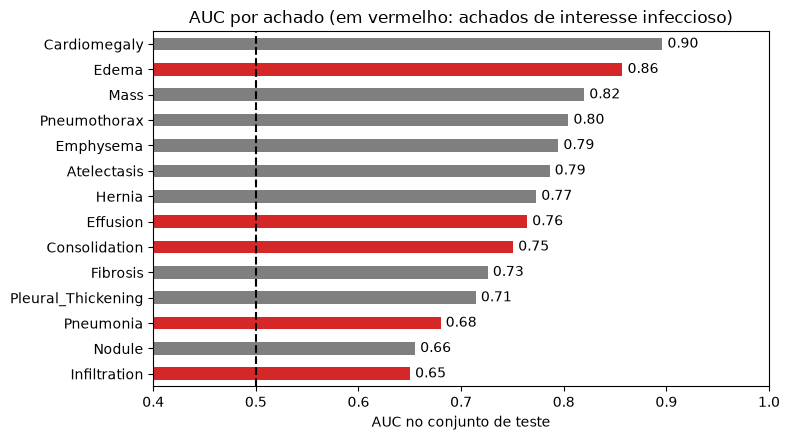

In [7]:
auc = pd.Series({a: roc_auc_score(teste[a], prob_teste[:, i]) for i, a in enumerate(ACHADOS)}).sort_values()
cores = ["#d62728" if a in ("Pneumonia", "Consolidation", "Infiltration", "Effusion", "Edema") else "#7f7f7f" for a in auc.index]
ax = auc.plot.barh(figsize=(8, 4.5), color=cores)
ax.axvline(0.5, ls="--", c="k"); ax.set_xlim(0.4, 1)
ax.set_xlabel("AUC no conjunto de teste"); ax.set_title("AUC por achado (em vermelho: achados de interesse infeccioso)")
for i, v in enumerate(auc): ax.text(v + 0.005, i, f"{v:.2f}", va="center")
plt.tight_layout(); plt.show()

### Onde o modelo olhou? Grad-CAM

Um bom resultado não basta: médicos precisam saber **por que** o modelo decidiu. O **Grad-CAM** calcula, a partir dos gradientes da última camada convolucional, **quais regiões da imagem mais pesaram** na probabilidade de um achado, e as mostra como um mapa de calor. Vermelho indica a região mais importante.

Escolhemos exames de teste **com pneumonia ou consolidação confirmadas** e mostramos o mapa para cada achado.

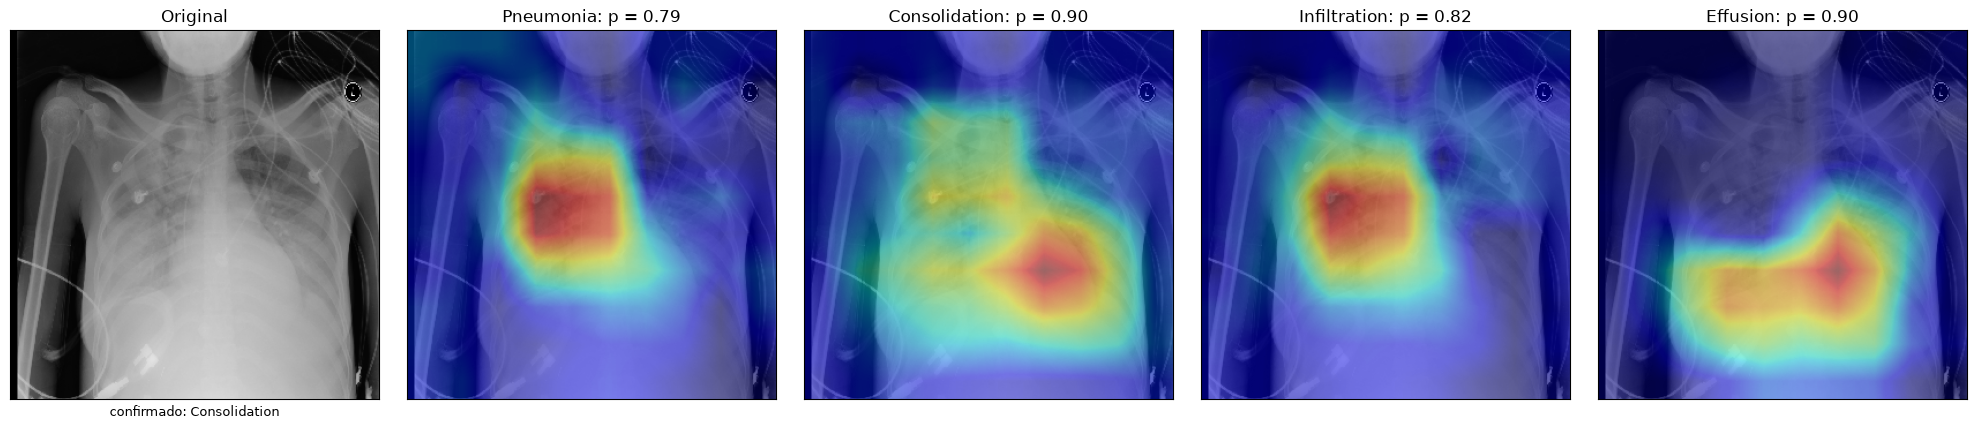

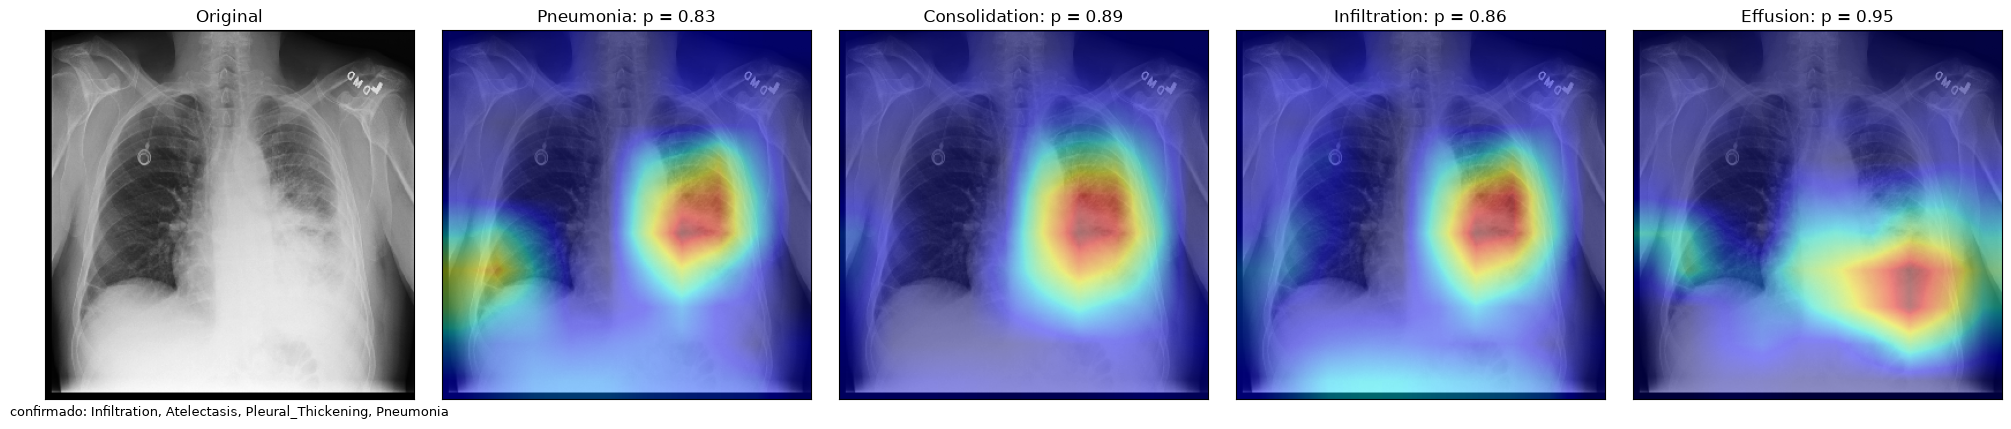

In [8]:
def grad_cam(imagem, indice_achado, camada="relu"):
    modelo_grad = keras.Model(modelo.input, [modelo.get_layer(camada).output, modelo.output])
    with tf.GradientTape() as tape:
        mapas, preds = modelo_grad(imagem[None, ...])
        alvo = preds[:, indice_achado]
    grads = tape.gradient(alvo, mapas)[0]
    pesos = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.nn.relu(tf.reduce_sum(mapas[0] * pesos, axis=-1))
    cam = tf.image.resize(cam[..., None], (320, 320))[..., 0].numpy()
    return cam / (cam.max() + 1e-8)

def mostrar_grad_cam(linha, achados_escolhidos):
    img = X_teste[linha]
    original = carregar(teste["Image"].iloc[linha])[..., 0]
    fig, eixos = plt.subplots(1, len(achados_escolhidos) + 1, figsize=(4 * (len(achados_escolhidos) + 1), 4))
    eixos[0].imshow(original, cmap="gray"); eixos[0].set_title("Original")
    reais = [a for a in ACHADOS if teste[a].iloc[linha] == 1]
    eixos[0].set_xlabel("confirmado: " + ", ".join(reais), fontsize=9)
    for ax, achado in zip(eixos[1:], achados_escolhidos):
        i = ACHADOS.index(achado)
        ax.imshow(original, cmap="gray")
        ax.imshow(grad_cam(img, i), cmap="jet", alpha=0.45)
        ax.set_title(f"{achado}: p = {prob_teste[linha, i]:.2f}")
    for ax in eixos: ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

casos = teste.index[(teste["Pneumonia"] == 1) | (teste["Consolidation"] == 1)]
casos = sorted(casos, key=lambda r: -max(prob_teste[r, ACHADOS.index("Pneumonia")], prob_teste[r, ACHADOS.index("Consolidation")]))[:2]
for linha in casos:
    mostrar_grad_cam(linha, ["Pneumonia", "Consolidation", "Infiltration", "Effusion"])

# Etapa 2: Avaliação de um teste diagnóstico
## Quanto confiar no resultado do modelo?

Para decidir, a probabilidade vira "positivo" ou "negativo" a partir de um **ponto de corte**. Comparando com o diagnóstico real, cada exame cai numa de quatro caixas: **verdadeiro positivo (VP)**, **falso negativo (FN)**, **falso positivo (FP)** ou **verdadeiro negativo (VN)**. Com elas calculamos:

| Métrica | Fórmula | Pergunta que responde |
|---|---|---|
| **Sensibilidade** | VP / (VP + FN) | Dos doentes, quantos o teste detecta? |
| **Especificidade** | VN / (VN + FP) | Dos sadios, quantos o teste reconhece? |
| **VPP** (valor preditivo positivo) | VP / (VP + FP) | Deu positivo: qual a chance de ser doença mesmo? |
| **VPN** (valor preditivo negativo) | VN / (VN + FN) | Deu negativo: qual a chance de estar mesmo sem doença? |

In [9]:
def metricas(y, p, corte):
    vn, fp, fn, vp = confusion_matrix(y, (p >= corte).astype(int), labels=[0, 1]).ravel()
    return {"prevalência": y.mean(), "sensibilidade": vp / (vp + fn), "especificidade": vn / (vn + fp),
            "VPP": vp / (vp + fp) if vp + fp else np.nan, "VPN": vn / (vn + fn), "AUC": roc_auc_score(y, p)}

INFECCIOSOS = ["Pneumonia", "Consolidation", "Infiltration", "Effusion", "Edema"]
tabela = pd.DataFrame({a: metricas(teste[a].values, prob_teste[:, ACHADOS.index(a)], corte=0.5) for a in INFECCIOSOS}).T
tabela.style.format("{:.1%}", subset=["prevalência", "sensibilidade", "especificidade", "VPP", "VPN"]).format("{:.3f}", subset=["AUC"])

,prevalência,sensibilidade,especificidade,VPP,VPN,AUC
Pneumonia,11.9%,60.0%,64.3%,18.5%,92.2%,0.680
Consolidation,12.6%,79.2%,58.0%,21.4%,95.1%,0.751
Infiltration,14.0%,64.4%,59.3%,20.5%,91.1%,0.650
Effusion,12.6%,73.6%,67.6%,24.7%,94.7%,0.764
Edema,11.9%,80.0%,78.1%,33.1%,96.7%,0.857


### A curva ROC e a escolha do ponto de corte

Cada ponto de corte gera um par (sensibilidade, 1 − especificidade). A **curva ROC** liga todos esses pares. Um corte baixo detecta mais doentes, mas gera mais falsos positivos; um corte alto faz o contrário. Em triagem de doenças infecciosas costuma-se priorizar a **sensibilidade**, para não deixar casos passarem.

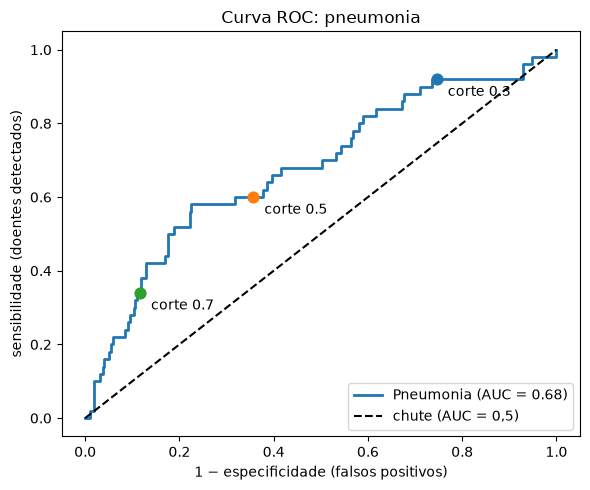

In [10]:
y_pn = teste["Pneumonia"].values
p_pn = prob_teste[:, ACHADOS.index("Pneumonia")]
fpr, tpr, cortes = roc_curve(y_pn, p_pn)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"Pneumonia (AUC = {roc_auc_score(y_pn, p_pn):.2f})")
ax.plot([0, 1], [0, 1], "k--", label="chute (AUC = 0,5)")
for c in (0.3, 0.5, 0.7):
    m = metricas(y_pn, p_pn, c)
    ax.scatter(1 - m["especificidade"], m["sensibilidade"], s=60, zorder=3)
    ax.annotate(f"corte {c}", (1 - m["especificidade"], m["sensibilidade"]), textcoords="offset points", xytext=(8, -12))
ax.set_xlabel("1 − especificidade (falsos positivos)"); ax.set_ylabel("sensibilidade (doentes detectados)")
ax.set_title("Curva ROC: pneumonia"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### O efeito da prevalência: o mesmo teste, contextos diferentes

Sensibilidade e especificidade são propriedades do teste. Já o **VPP depende da prevalência**, isto é, de quanto a doença é comum no grupo testado. Pelo teorema de Bayes:

$$VPP = \frac{sens \cdot prev}{sens \cdot prev + (1 - espec)(1 - prev)}$$

Na prática: o mesmo teste pode ter um VPP alto **num surto**, com muitos doentes, e um VPP baixo **numa triagem da população geral**, onde a maioria dos positivos será falso.

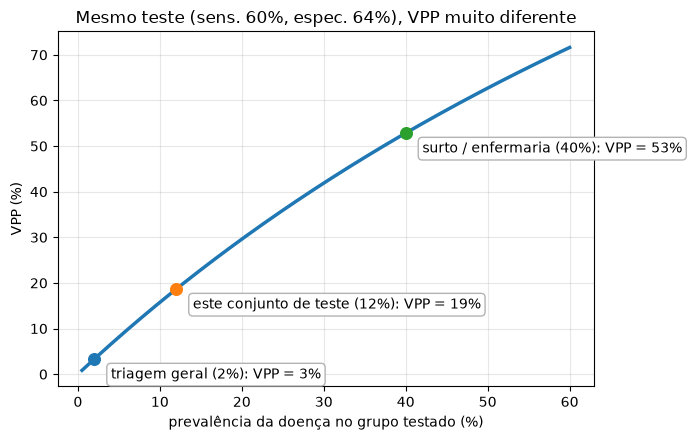

In [11]:
m = metricas(y_pn, p_pn, 0.5)
prev = np.linspace(0.005, 0.6, 200)
vpp = m["sensibilidade"] * prev / (m["sensibilidade"] * prev + (1 - m["especificidade"]) * (1 - prev))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(prev * 100, vpp * 100, lw=2.5)
for p0, nome in [(0.02, "triagem geral (2%)"), (0.12, "este conjunto de teste (12%)"), (0.40, "surto / enfermaria (40%)")]:
    v = m["sensibilidade"] * p0 / (m["sensibilidade"] * p0 + (1 - m["especificidade"]) * (1 - p0))
    ax.scatter(p0 * 100, v * 100, s=70, zorder=3)
    ax.annotate(f"{nome}: VPP = {v:.0%}", (p0 * 100, v * 100), xytext=(12, -14), textcoords="offset points",
                bbox=dict(boxstyle="round", fc="white", ec="0.7"))
ax.set_xlabel("prevalência da doença no grupo testado (%)"); ax.set_ylabel("VPP (%)")
ax.set_title(f"Mesmo teste (sens. {m['sensibilidade']:.0%}, espec. {m['especificidade']:.0%}), VPP muito diferente")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Quão incerta é a AUC? Intervalo de confiança por bootstrap

Com apenas 420 imagens de teste, a AUC tem incerteza. O **bootstrap** sorteia, com reposição, 1.000 novos conjuntos de teste do mesmo tamanho, calcula a AUC em cada um e usa a distribuição resultante para dar um **intervalo de confiança de 95%**.

In [12]:
rng = np.random.default_rng(0)
def ic_bootstrap(y, p, n=1000):
    aucs = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if 0 < y[idx].sum() < len(y): aucs.append(roc_auc_score(y[idx], p[idx]))
    return np.percentile(aucs, [2.5, 97.5])

for a in INFECCIOSOS:
    y, p = teste[a].values, prob_teste[:, ACHADOS.index(a)]
    li, ls = ic_bootstrap(y, p)
    print(f"{a:14s} AUC = {roc_auc_score(y, p):.3f}   IC 95%: [{li:.3f} ; {ls:.3f}]")

Pneumonia      AUC = 0.680   IC 95%: [0.596 ; 0.766]


Consolidation  AUC = 0.751   IC 95%: [0.675 ; 0.825]


Infiltration   AUC = 0.650   IC 95%: [0.577 ; 0.720]


Effusion       AUC = 0.764   IC 95%: [0.695 ; 0.824]


Edema          AUC = 0.857   IC 95%: [0.793 ; 0.909]


### A probabilidade é confiável? Calibração

Se o modelo diz "80% de chance", a doença deveria estar presente em cerca de 80% desses casos. A **curva de calibração** compara a probabilidade prevista com a frequência real. Um modelo bem calibrado fica sobre a diagonal. Este modelo foi treinado com perda ponderada e **superestima** as probabilidades: a curva fica abaixo da diagonal. Para usar a probabilidade diretamente, ela precisaria ser recalibrada.

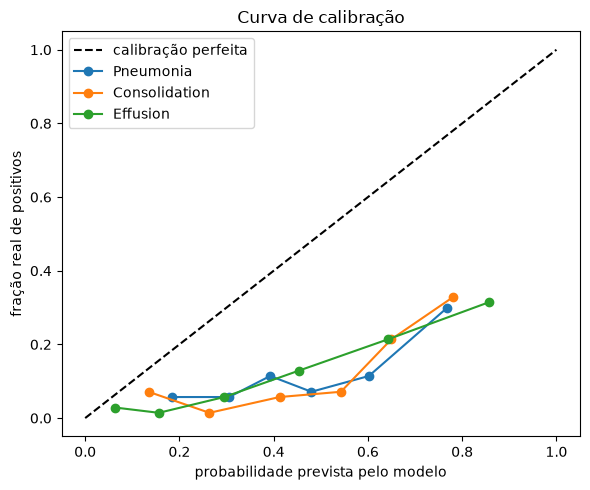

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", label="calibração perfeita")
for a in ["Pneumonia", "Consolidation", "Effusion"]:
    frac, media = calibration_curve(teste[a], prob_teste[:, ACHADOS.index(a)], n_bins=6, strategy="quantile")
    ax.plot(media, frac, "o-", label=a)
ax.set_xlabel("probabilidade prevista pelo modelo"); ax.set_ylabel("fração real de positivos")
ax.set_title("Curva de calibração"); ax.legend(); plt.tight_layout(); plt.show()

# Etapa 3: Prognóstico
## Análise de sobrevida no ensaio clínico ACTG 175 (HIV)

O **ACTG 175** foi um ensaio clínico randomizado com **2.139 adultos com HIV**, comparando quatro esquemas antirretrovirais:

| Código | Braço |
|---|---|
| 0 | zidovudina (ZDV) sozinha |
| 1 | ZDV + didanosina (ddI) |
| 2 | ZDV + zalcitabina |
| 3 | didanosina sozinha |

O **evento** (desfecho ruim) é: queda de mais de 50% nos linfócitos CD4, evolução para AIDS ou óbito. Cada paciente tem o **tempo** até o evento ou até o fim do acompanhamento.

Quem terminou o estudo sem o evento é um dado **censurado**: sabemos apenas que ficou bem *até aquele dia*. Métodos de sobrevida usam essa informação parcial sem descartá-la.

In [14]:
actg = pd.read_csv("dados/actg175.csv")
BRACOS = {0: "ZDV", 1: "ZDV + ddI", 2: "ZDV + zalcitabina", 3: "ddI"}
actg["braço"] = actg["trt"].map(BRACOS)

print(f"{len(actg)} pacientes | {actg['cid'].sum()} eventos ({actg['cid'].mean():.0%}) | acompanhamento máximo: {actg['time'].max()} dias")
actg[["time", "cid", "braço", "age", "cd40", "karnof", "symptom"]].head()

2139 pacientes | 521 eventos (24%) | acompanhamento máximo: 1231 dias


,time,cid,braço,age,cd40,karnof,symptom
0,948,0,ZDV + zalcitabina,48,422,100,0
1,1002,1,ddI,61,162,90,0
2,961,0,ddI,45,326,90,0
3,1166,0,ddI,47,287,100,0
4,1090,0,ZDV,43,504,100,0


### A curva de Kaplan-Meier

A curva de **Kaplan-Meier** estima, a cada dia, a proporção de pacientes **ainda livres do evento**, levando em conta os censurados. Comparamos os quatro braços do estudo; o **teste log-rank** verifica se as diferenças entre as curvas podem ser só acaso.

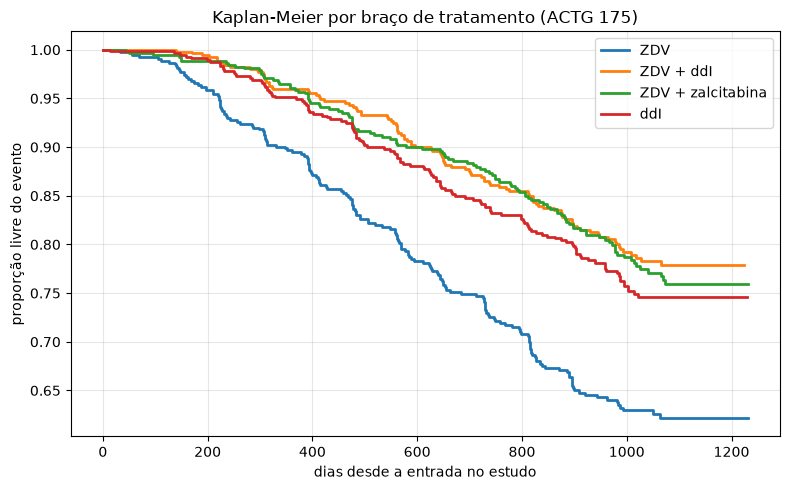

Teste log-rank (4 braços): p = 1.2e-10


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
for codigo, nome in BRACOS.items():
    grupo = actg[actg["trt"] == codigo]
    KaplanMeierFitter().fit(grupo["time"], grupo["cid"], label=nome).plot_survival_function(ax=ax, ci_show=False, lw=2)
ax.set_xlabel("dias desde a entrada no estudo"); ax.set_ylabel("proporção livre do evento")
ax.set_title("Kaplan-Meier por braço de tratamento (ACTG 175)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

teste_lr = multivariate_logrank_test(actg["time"], actg["trt"], actg["cid"])
print(f"Teste log-rank (4 braços): p = {teste_lr.p_value:.1e}")

### O modelo de Cox: o peso de cada fator

O **modelo de riscos proporcionais de Cox** estima o efeito de vários fatores ao mesmo tempo sobre o risco do evento. Cada fator ganha um **hazard ratio (HR)**:

- **HR > 1**: aumenta o risco (ex.: 1,5 = risco 50% maior);
- **HR < 1**: protege (ex.: 0,6 = risco 40% menor).

A **concordância (C-index)** mede se o modelo ordena bem os pacientes por risco: 0,5 é acaso e 1,0 é perfeito.

In [16]:
dados_cox = actg[["time", "cid", "age", "cd40", "karnof", "symptom", "drugs", "str2"]].copy()
dados_cox["cd40_por_100"] = dados_cox.pop("cd40") / 100          # HR por 100 células de CD4
for codigo in (1, 2, 3):
    dados_cox[f"tratamento: {BRACOS[codigo]}"] = (actg["trt"] == codigo).astype(int)
dados_cox = dados_cox.rename(columns={"age": "idade", "karnof": "Karnofsky", "symptom": "sintomático",
                                      "drugs": "uso de drogas IV", "str2": "antirretroviral prévio"})

cox = CoxPHFitter().fit(dados_cox, duration_col="time", event_col="cid")
resumo = cox.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
resumo.columns = ["HR", "IC 95% inf.", "IC 95% sup.", "p"]
print(f"C-index: {cox.concordance_index_:.3f}")
resumo.round(3)

C-index: 0.687


,HR,IC 95% inf.,IC 95% sup.,p
covariate,,,,
idade,1.009,0.999,1.019,0.070
Karnofsky,0.976,0.963,0.990,0.001
sintomático,1.570,1.285,1.917,0.000
uso de drogas IV,0.723,0.543,0.963,0.027
antirretroviral prévio,1.431,1.186,1.727,0.000
cd40_por_100,0.698,0.641,0.760,0.000
tratamento: ZDV + ddI,0.464,0.364,0.592,0.000
tratamento: ZDV + zalcitabina,0.518,0.408,0.657,0.000
tratamento: ddI,0.573,0.457,0.719,0.000


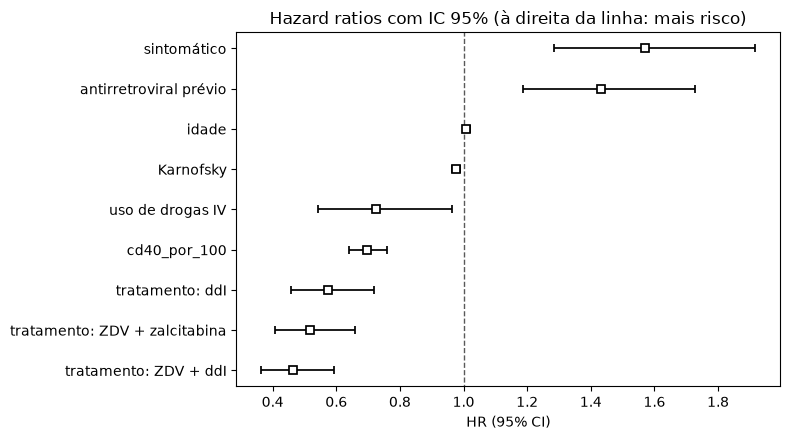

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cox.plot(hazard_ratios=True, ax=ax)
ax.set_title("Hazard ratios com IC 95% (à direita da linha: mais risco)")
plt.tight_layout(); plt.show()

# Etapa 4: Tratamento
## O tratamento funciona? E para quem funciona mais?

Comparamos o braço **ZDV + ddI** (tratamento) com **ZDV sozinha** (controle). Como o estudo foi **randomizado**, os dois grupos são comparáveis e a diferença nos desfechos pode ser atribuída ao tratamento.

Duas medidas clássicas:
- **Redução absoluta de risco (RAR)**: diferença entre a taxa de eventos do controle e a do tratado. Dela vem o **NNT**, o número necessário tratar para evitar um evento: NNT = 1 / RAR;
- **Odds ratio (OR)**, estimado por **regressão logística**: OR < 1 indica que o tratamento reduz as chances do evento.

In [18]:
ensaio = actg[actg["trt"].isin([0, 1])].copy()
ensaio["tratado"] = (ensaio["trt"] == 1).astype(int)

taxa = ensaio.groupby("tratado")["cid"].mean()
rar = taxa[0] - taxa[1]
print(f"Taxa de eventos  ZDV sozinha: {taxa[0]:.1%}  |  ZDV + ddI: {taxa[1]:.1%}")
print(f"Redução absoluta de risco: {rar:.1%}  ->  NNT ≈ {1 / rar:.0f} pacientes")

COVARIAVEIS = ["age", "wtkg", "karnof", "cd40", "cd80", "symptom", "drugs", "homo", "hemo", "str2", "race", "gender"]
logit = LogisticRegression(max_iter=5000).fit(ensaio[["tratado"] + COVARIAVEIS], ensaio["cid"])
print(f"Odds ratio do tratamento (ajustado pelas covariáveis): {np.exp(logit.coef_[0][0]):.2f}")

Taxa de eventos  ZDV sozinha: 34.0%  |  ZDV + ddI: 19.7%
Redução absoluta de risco: 14.3%  ->  NNT ≈ 7 pacientes


Odds ratio do tratamento (ajustado pelas covariáveis): 0.44


### Efeito individual com machine learning: o T-learner

A RAR é uma **média**; o benefício pode variar de paciente para paciente. O **T-learner** estima o efeito individual com **dois modelos** (aqui, florestas aleatórias):

1. um modelo aprende o risco do evento **entre os tratados**;
2. outro aprende o risco **entre os controles**;
3. para cada paciente, calculamos os dois riscos. A diferença, risco sem tratamento menos risco com tratamento, é o **benefício previsto**.

Para avaliar com honestidade, usamos **validação cruzada em 5 partes**: o benefício de cada paciente é previsto por modelos que **não o viram no treino**.

In [19]:
from sklearn.model_selection import StratifiedKFold

def floresta():
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=0)

ensaio["risco_sem"] = np.nan
ensaio["risco_com"] = np.nan
partes = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
for idx_treino, idx_aval in partes.split(ensaio, ensaio["tratado"] * 2 + ensaio["cid"]):
    tr, av = ensaio.iloc[idx_treino], ensaio.iloc[idx_aval]
    m_com = floresta().fit(tr.loc[tr.tratado == 1, COVARIAVEIS], tr.loc[tr.tratado == 1, "cid"])
    m_sem = floresta().fit(tr.loc[tr.tratado == 0, COVARIAVEIS], tr.loc[tr.tratado == 0, "cid"])
    ensaio.iloc[idx_aval, ensaio.columns.get_loc("risco_sem")] = m_sem.predict_proba(av[COVARIAVEIS])[:, 1]
    ensaio.iloc[idx_aval, ensaio.columns.get_loc("risco_com")] = m_com.predict_proba(av[COVARIAVEIS])[:, 1]

ensaio["benefício_previsto"] = ensaio["risco_sem"] - ensaio["risco_com"]
colunas = ["age", "cd40", "karnof", "symptom", "risco_sem", "risco_com", "benefício_previsto"]
ensaio[colunas].sort_values("benefício_previsto").iloc[[0, 1, -2, -1]].round(3)

,age,cd40,karnof,symptom,risco_sem,risco_com,benefício_previsto
1935,35,300,90,1,0.177,0.232,-0.054
209,30,311,100,1,0.196,0.246,-0.049
469,43,319,100,0,0.498,0.139,0.359
1952,45,420,100,0,0.454,0.093,0.361


### O modelo acerta quem se beneficia mais?

Dividimos os pacientes em **três grupos pelo benefício previsto** e, em cada grupo, medimos a **redução de risco observada de fato**, comparando controles e tratados daquele grupo. Se o modelo funciona, a redução observada deve crescer com o benefício previsto.

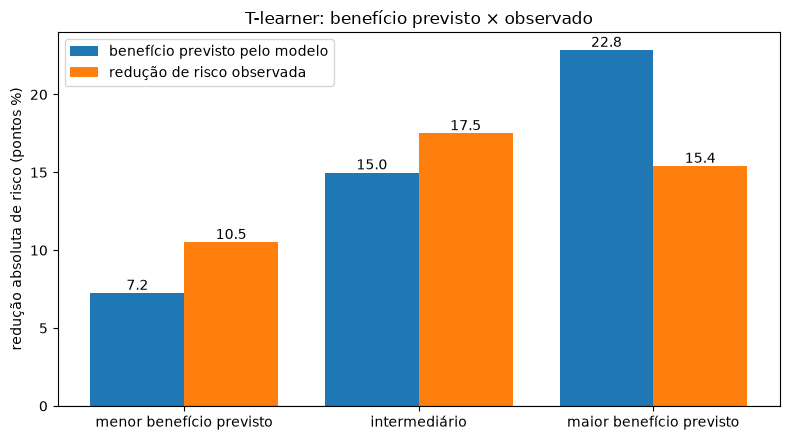

In [20]:
ensaio["grupo"] = pd.qcut(ensaio["benefício_previsto"], 3, labels=["menor benefício previsto", "intermediário", "maior benefício previsto"])
obs = ensaio.groupby("grupo", observed=True)[["tratado", "cid"]].apply(
    lambda g: g.loc[g.tratado == 0, "cid"].mean() - g.loc[g.tratado == 1, "cid"].mean())
prev = ensaio.groupby("grupo", observed=True)["benefício_previsto"].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(3)
b1 = ax.bar(x - 0.2, prev * 100, 0.4, label="benefício previsto pelo modelo")
b2 = ax.bar(x + 0.2, obs * 100, 0.4, label="redução de risco observada")
ax.bar_label(b1, fmt="%.1f"); ax.bar_label(b2, fmt="%.1f")
ax.set_xticks(x); ax.set_xticklabels(obs.index); ax.axhline(0, c="k", lw=0.8)
ax.set_ylabel("redução absoluta de risco (pontos %)"); ax.set_title("T-learner: benefício previsto × observado")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

**Como ler:** o grupo que o modelo apontou como de **menor benefício** de fato teve a **menor redução de risco**. Entre os outros dois grupos, a diferença não é clara. O ddI ajudou a maioria dos pacientes de forma parecida, e estimar efeitos individuais com precisão exige estudos bem maiores. É por isso que esses modelos são usados para **gerar hipóteses** sobre subgrupos, a serem confirmadas em novos estudos.

# Resumo

| Etapa | O que vimos | Resultado |
|---|---|---|
| **Diagnóstico** | DenseNet121 já treinada em raio-X, com Grad-CAM mostrando a região da decisão | AUC de 0,65 a 0,90 conforme o achado |
| **Avaliação** | sensibilidade, especificidade, VPP/VPN, ROC, bootstrap e calibração | o **VPP depende da prevalência**; o modelo precisa de recalibração |
| **Prognóstico** | Kaplan-Meier, log-rank e Cox no ensaio ACTG 175 | a terapia combinada adia o evento; CD4 baixo e sintomas aumentam o risco |
| **Tratamento** | RAR, NNT, odds ratio e T-learner | benefício médio claro; o T-learner identifica quem se beneficia menos |

**Exercícios sugeridos:**
1. Troque o achado da etapa 2 (ex.: `Edema`) e compare sensibilidade, especificidade e VPP.
2. Escolha um ponto de corte que garanta 90% de sensibilidade para pneumonia e veja o que acontece com o VPP.
3. Na etapa 3, compare as curvas de Kaplan-Meier de pacientes sintomáticos e assintomáticos.
4. Na etapa 4, compare o braço **ZDV + zalcitabina** com o controle.